In [1]:
pip install ultralytics

Note: you may need to restart the kernel to use updated packages.


In [7]:
from ultralytics import YOLO
from PIL import Image
from IPython.display import display

In [2]:
inference_model=YOLO(r"D:\ASL_Project\workflow\YOLOv8\models\best2.pt") # Enter path to model best2.pt


image 1/1 D:\ASL_Project\workflow\YOLOv8\Dataset\test_images\test4.jpg: 384x640 1 Idol, 1 Person, 210.3ms
Speed: 1939.9ms preprocess, 210.3ms inference, 10.6ms postprocess per image at shape (1, 3, 384, 640)


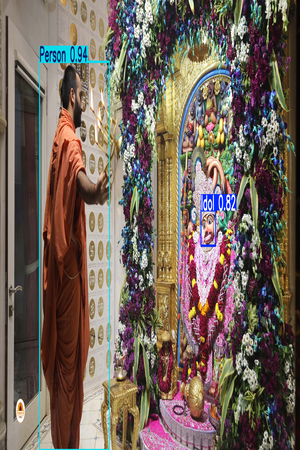

In [19]:
results = inference_model.predict(r"D:\ASL_Project\workflow\YOLOv8\Dataset\test_images\test4.jpg") # Use path to test image

img = Image.fromarray(results[0].plot()[..., ::-1])

img_resized = img.resize((300, 450), Image.Resampling.LANCZOS)


display(img_resized)

In [ ]:
result= results[0] # To check output values
for box in result.boxes:
    print("Object type:", box.cls[0].item()) # [0].tolist() or [0].item() is only used to unpack values from tensors
    print("Object name:", result.names[int(box.cls[0].item())])
    print("Coordinates:", box.xyxy[0].tolist())
    print("Probability:", box.conf[0].item())
    print("-" * 30)

Object type: 1.0
Object name: Person
Coordinates: [317.7828674316406, 186.80398559570312, 880.9773559570312, 1358.0]
Probability: 0.9372404217720032
------------------------------
Object type: 0.0
Object name: Idol
Coordinates: [1616.5196533203125, 634.9444580078125, 1734.300537109375, 741.2554321289062]
Probability: 0.8247293829917908
------------------------------


In [7]:
result.names[int(box.cls[0].item())] # To check object names in image from [0] to [len(result.boxes)]

'Idol'